# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sentence_transformers import SentenceTransformer
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation


# Load Dataset

In [2]:
#implemented to not cut off the lines in the results
pd.set_option('display.max_colwidth', None)

nist = pd.read_csv("NIST_800_53r5.csv")

In [3]:
nist.head()

,identifier,name,control_text,discussion,related,Unnamed: 5
0,AC-1,Policy and Procedures,"\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events].","Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. Policies and procedures contribute to security and privacy assurance. Therefore, it is important that security and privacy programs collaborate on the development of access control policy and procedures. Security and privacy program policies and procedures at the organization level are preferable, in general, and may obviate the need for mission- or system-specific policies and procedures. The policy can be included as part of the general security and privacy policy or be represented by multiple policies reflecting the complex nature of organizations. Procedures can be established for security and privacy programs, for mission or business processes, and for systems, if needed. Procedures describe how the policies or controls are implemented and can be directed at the individual or role that is the object of the procedure. Procedures can be documented in system security and privacy plans or in one or more separate documents. Events that may precipitate an update to access control policy and procedures include assessment or audit findings, security incidents or breaches, or changes in laws, executive orders, directives, regulations, policies, standards, and guidelines. Simply restating controls does not constitute an organizational policy or procedure.","IA-1, PM-9, PM-24, PS-8, SI-12.",NaN
1,AC-2,Account Management,"\na. Define and document the types of accounts allowed and specifically prohibited for use within the system;\nb. Assign account managers;\nc. Require [Assignment: organization-defined prerequisites and criteria] for group and role membership;\nd. Specify:\n\n1. Authorized users of the system;\n2. Group and role membership; and\n3. Access authorizations (i.e., privileges) and [Assignment: organization-defined attributes (as required)] for each account;\ne. Require approvals by [Assignment: organization-defined personnel or roles] for requests to create accounts;\nf. Create, enable, modify, disable, and remove accounts in accordance with [Assignment: organization-defined policy, procedures, prerequisites, and criteria];\ng. Monitor the use of accounts;\nh. Notify account managers and [Assignment: organization-defined personnel or roles] within:\n\n1. [Assignment: organization-defined time period] when accounts are no longer required;\n2. [Assignment: organization-defined time period] when users are terminated or transferred; and\n3. [Assignment: organization-defined time period] when system usage or need-to-know changes for an individual;\ni. Authorize access to the system based on:\n\n1. A valid access authorization;\n2. Intended system usage; and\n3. [Assignm

Loaded the NIST dataset and displayed the first few rows.

# Explore Dataset

In [4]:
nist.shape

(1189, 6)

In [5]:
nist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   identifier    1189 non-null   object
 1   name          1189 non-null   object
 2   control_text  1189 non-null   object
 3   discussion    1009 non-null   object
 4   related       1187 non-null   object
 5   Unnamed: 5    2 non-null      object
dtypes: object(6)
memory usage: 55.9+ KB


The dataset has 6 columns and 1189 rows. There are some missing values in the discussion and Unnamed: 5 column. This means that 180 controls do not have a 'why' discussion. In NIST every row is a legal requirement and thus must be accounted for. No rows will be deleted instead they will be filled with an empty string ensuring that no regulatory controls are excluded from the model. The Unnamed: 5 will be dropped since it holds no useful data for this analysis.

# Clean Dataset

In [6]:
#create a copy
nist_clean = nist.copy()

#drop Unnamed column
nist_clean = nist_clean.drop(columns=['Unnamed: 5'])


In [7]:
nist_clean.head(1)

,identifier,name,control_text,discussion,related
0,AC-1,Policy and Procedures,"\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events].","Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. Policies and procedures contribute to security and privacy assurance. Therefore, it is important that security and privacy programs collaborate on the development of access control policy and procedures. Security and privacy program policies and procedures at the organization level are preferable, in general, and may obviate the need for mission- or system-specific policies and procedures. The policy can be included as part of the general security and privacy policy or be represented by multiple policies reflecting the complex nature of organizations. Procedures can be established for security and privacy programs, for mission or business processes, and for systems, if needed. Procedures describe how the policies or controls are implemented and can be directed at the individual or role that is the object of the procedure. Procedures can be documented in system security and privacy plans or in one or more separate documents. Events that may precipitate an update to access control policy and procedures include assessment or audit findings, security incidents or breaches, or changes in laws, executive orders, directives, regulations, policies, standards, and guidelines. Simply restating controls does not constitute an organizational policy or procedure.","IA-1, PM-9, PM-24, PS-8, SI-12."


In [8]:
#handling the missing values
nist_clean['discussion'] = nist_clean['discussion'].fillna(' ')


In [9]:
#merge text columns
nist_clean['combined_text'] = nist_clean['control_text'] + ' ' + nist_clean['discussion']

nist_clean.head(1)

,identifier,name,control_text,discussion,related,combined_text
0,AC-1,Policy and Procedures,"\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events].","Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. Policies and procedures contribute to security and privacy assurance. Therefore, it is important that security and privacy programs collaborate on the development of access control policy and procedures. Security and privacy program policies and procedures at the organization level are preferable, in general, and may obviate the need for mission- or system-specific policies and procedures. The policy can be included as part of the general security and privacy policy or be represented by multiple policies reflecting the complex nature of organizations. Procedures can be established for security and privacy programs, for mission or business processes, and for systems, if needed. Procedures describe how the policies or controls are implemented and can be directed at the individual or role that is the object of the procedure. Procedures can be documented in system security and privacy plans or in one or more separate documents. Events that may precipitate an update to access control policy and procedures include assessment or audit findings, security incidents or breaches, or changes in laws, executive orders, directives, regulations, policies, standards, and guidelines. Simply restating controls does not constitute an organizational policy or procedure.","IA-1, PM-9, PM-24, PS-8, SI-12.","\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]. Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. Policies and pro

In [10]:
nist_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   identifier     1189 non-null   object
 1   name           1189 non-null   object
 2   control_text   1189 non-null   object
 3   discussion     1189 non-null   object
 4   related        1187 non-null   object
 5   combined_text  1189 non-null   object
dtypes: object(6)
memory usage: 55.9+ KB


# NLP Preprocessing

In [11]:
#download resources

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_grc_text(text):
    '''
    Cleans and normalize NIST GRC text by removing placeholders, punctuation, and stopwords.

    Args:
    text (str): The text to be cleaned.

    Returns:
    str: The cleaned text

    '''
    #remove NIST placeholders like [Assignment: ...]
    text = re.sub(r'\[.*?\]', '', text)
    #remove newlines (\n) and special characters
    text = re.sub(r'\s+', ' ', text) #replace multiple spaces/newlines with single space
    text = re.sub(r'[^\w\s]', '', text) #remove punctuation
    #lowercase and tokenize
    words = text.lower().split()
    #lemmatize and remove stopwords
    cleaned = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(cleaned)

#apply cleaning
nist_clean['processed_text'] = nist_clean['combined_text'].apply(clean_grc_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [12]:
nist_clean.head(1)

,identifier,name,control_text,discussion,related,combined_text,processed_text
0,AC-1,Policy and Procedures,"\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events].","Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. Policies and procedures contribute to security and privacy assurance. Therefore, it is important that security and privacy programs collaborate on the development of access control policy and procedures. Security and privacy program policies and procedures at the organization level are preferable, in general, and may obviate the need for mission- or system-specific policies and procedures. The policy can be included as part of the general security and privacy policy or be represented by multiple policies reflecting the complex nature of organizations. Procedures can be established for security and privacy programs, for mission or business processes, and for systems, if needed. Procedures describe how the policies or controls are implemented and can be directed at the individual or role that is the object of the procedure. Procedures can be documented in system security and privacy plans or in one or more separate documents. Events that may precipitate an update to access control policy and procedures include assessment or audit findings, security incidents or breaches, or changes in laws, executive orders, directives, regulations, policies, standards, and guidelines. Simply restating controls does not constitute an organizational policy or procedure.","IA-1, PM-9, PM-24, PS-8, SI-12.","\na. Develop, document, and disseminate to [Assignment: organization-defined personnel or roles]:\n\n1. [Selection (one or more): Organization-level; Mission/business process-level; System-level] access control policy that:\n\n(a) Addresses purpose, scope, roles, responsibilities, management commitment, coordination among organizational entities, and compliance; and\n(b) Is consistent with applicable laws, executive orders, directives, regulations, policies, standards, and guidelines; and\n2. Procedures to facilitate the implementation of the access control policy and the associated access controls;\nb. Designate an [Assignment: organization-defined official] to manage the development, documentation, and dissemination of the access control policy and procedures; and\nc. Review and update the current access control:\n\n1. Policy [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]; and\n2. Procedures [Assignment: organization-defined frequency] and following [Assignment: organization-defined events]. Access control policy and procedures address the controls in the AC family that are implemented within systems and organizations. The risk management strategy is an important factor in establishing such policies and procedures. P

Raw NIST SP 800-53 text contains "noise" such as legal placeholders, formatting characters, and common words that can hinder machine learning performance. To prepare the data, we implement a custom pipeline that utilizes Regex to strip  placeholders and removes newlines and punctuation to focus on core keywords. The text is then normalized to lowercase and processed through the WordNet Lemmatizer to reduce words to their base, which helps group related concepts and reduces data complexity. Finally, the NLTK library is used to filter out high frequency stop words that carry little semantic weight.

In [13]:
#initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=1500) #limits vocabulary to the top 1500 most important words across corpus

#transforms cleaned text into a numerical sparse matrix
X = tfidf.fit_transform(nist_clean['processed_text'])

print('Feature matrix shape:', X.shape)
nist_clean[['identifier', 'processed_text']].head()

Feature matrix shape: (1189, 1500)


,identifier,processed_text
0,AC-1,develop document disseminate 1 access control policy address purpose scope role responsibility management commitment coordination among organizational entity compliance b consistent applicable law executive order directive regulation policy standard guideline 2 procedure facilitate implementation access control policy associated access control b designate manage development documentation dissemination access control policy procedure c review update current access control 1 policy following 2 procedure following access control policy procedure address control ac family implemented within system organization risk management strategy important factor establishing policy procedure policy procedure contribute security privacy assurance therefore important security privacy program collaborate development access control policy procedure security privacy program policy procedure organization level preferable general may obviate need mission systemspecific policy procedure policy included part general security privacy policy represented multiple policy reflecting complex nature organization procedure established security privacy program mission business process system needed procedure describe policy control implemented directed individual role object procedure procedure documented system security privacy plan one separate document event may precipitate update access control policy procedure include assessment audit finding security incident breach change law executive order directive regulation policy standard guideline simply restating control constitute organizational policy procedure
1,AC-2,define document type account allowed specifically prohibited use within system b assign account manager c require group role membership specify 1 authorized user system 2 group role membership 3 access authorization ie privilege account e require approval request create account f create enable modify disable remove account accordance g monitor use account h notify account manager within 1 account longer required 2 user terminated transferred 3 system usage needtoknow change individual authorize access system based 1 valid access authorization 2 intended system usage 3 j review account compliance account management requirement k establish implement process changing shared group account authenticator deployed individual removed group l align account management process personnel termination transfer process example system account type include individual shared group system guest anonymous emergency developer temporary service identification authorized system user specification access privilege reflect requirement control security plan user requiring administrative privilege system account receive additional scrutiny organizational personnel responsible approving account privileged access including system owner mission business owner senior agency information security officer senior agency official privacy type account organization may wish prohibit due increased risk include shared group emergency anonymous temporary guest account access involves personally identifiable information security program collaborate senior agency official privacy establish specific condition group role membership specify authorized user group role membership access authorization account create adjust remove system account accordance organizational policy policy include information account expiration date factor trigger disabling account organization may choose define access privilege attribute account type account combination two example attribute required authorizing access include restriction time day day week point origin defining system account attribute organization consider systemrelated requirement missionbusiness requirement failure consider factor could affect system availability temporary emergency account intended shortterm use organization establish temporary account part normal account activation procedure need shortterm acc

Because machine learning algorithms require numerical input rather than raw text, cleaned data is transformed into a mathematical representation using TF-IDF (Term Frequency-Inverse Document Frequency). This method calculates Term Frequency to measure how often a keyword appears in a specific control, while applying Inverse Document Frequency to penalize common words across the entire framework, effectively highlighting unique, identifying GRC terms. We limit the output to the top 1,500 features that captures the most significant terminology for our classification models.

# EDA

In [14]:
#prepare Target Variable (The 'Family' of the control, e.g., 'AC', 'AU')

#extract the first two letters from the 'identifier' column
nist_clean['family'] = nist_clean['identifier'].str[:2]


/tmp/ipython-input-750/3726340709.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=nist_clean, x='family', order=nist_clean['family'].value_counts().index, palette='viridis')


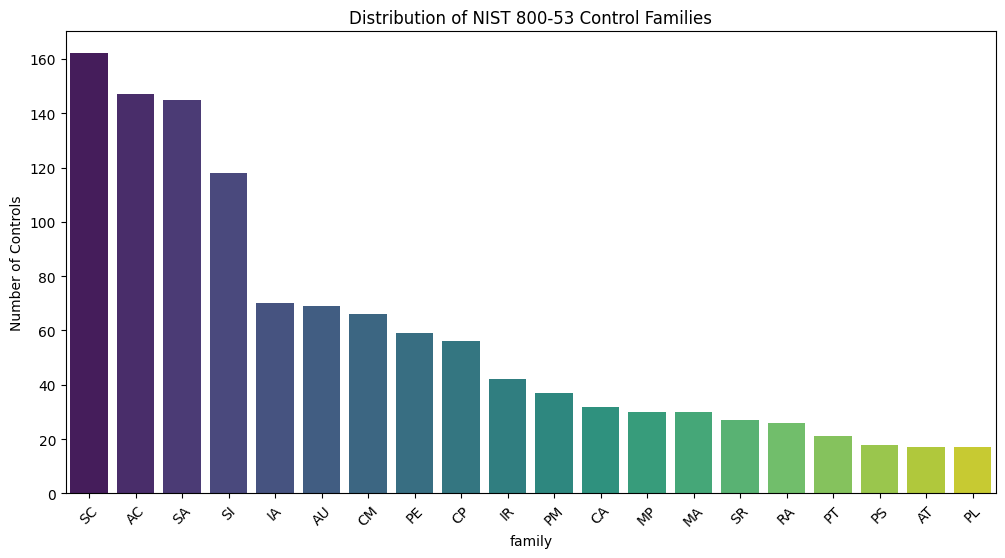

In [15]:
#displaying the distribution of the 20 control families (Target Variable)
plt.figure(figsize=(12, 6))
sns.countplot(data=nist_clean, x='family', order=nist_clean['family'].value_counts().index, palette='viridis')
plt.title('Distribution of NIST 800-53 Control Families')
plt.xticks(rotation=45)
plt.ylabel('Number of Controls')
plt.show()

The dataset is highly imbalanced, with the SC family containing 10x more samples than minority classes.
An analysis of the corpus reveals a severe class imbalance, with the System and Communications Protection (SC) family dominating the dataset, while several minority families such as Awareness and Training (AT) and Planning (PL) made up of the least amount of information in the corpus. This disparity highlights the necessity of the Synthetic Minority Over-sampling Technique (SMOTE) to prevent the classifier from developing a majority-class bias."

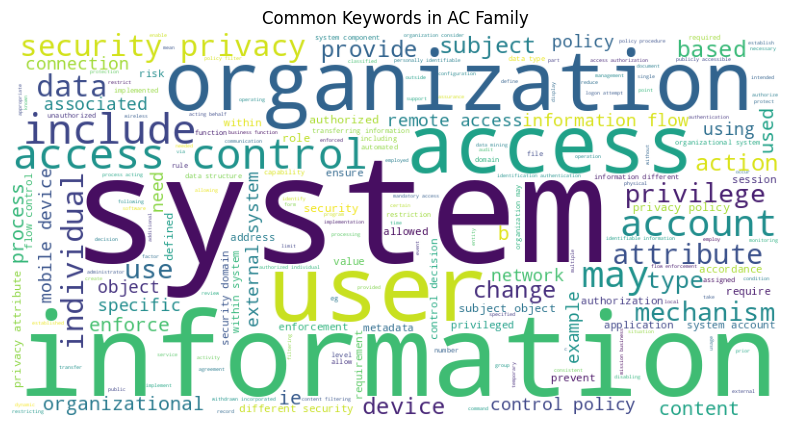

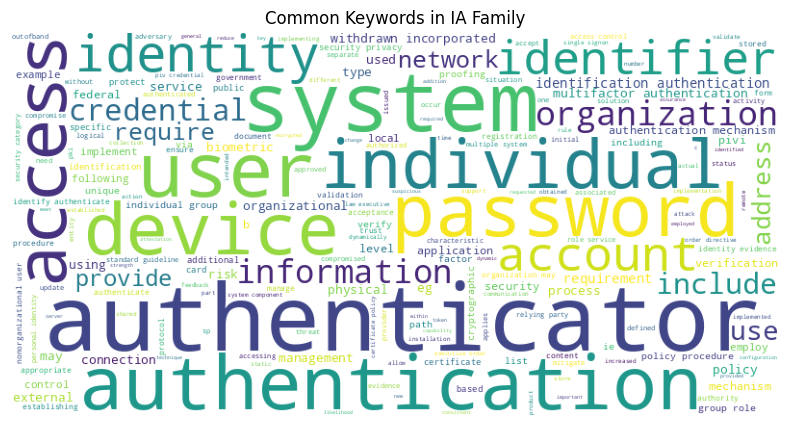

In [16]:

def plot_wordcloud(family_code):
    """
    Generates and displays a visual WordCloud for a specific NIST 800-53 control family.

    Args: family_code (str): The 2-letter code representing the control family.

    Returns: WordCloud visualization of the most common keywords in the specified family.

    """

    text = " ".join(nist_clean[nist_clean['family'] == family_code]['processed_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.title(f'Common Keywords in {family_code} Family')
    plt.axis('off')
    plt.show()

plot_wordcloud('AC')
plot_wordcloud('IA')

Visualizing keywords reveals that many families such as AC and IA frequently use terms like 'system,' 'access,' and 'user,' creating high semantic noise and overlapping.

In [17]:
#initializes the LDA model
lda = LatentDirichletAllocation(n_components=5, random_state=42) #looks at 5 distinct clusters within the corpus
lda.fit(X)

#retrieves feature names from the TF-IDF vectorizer for mapping
words = tfidf.get_feature_names_out()

#iterates through each discovered topic to dislay the most signifiicant terms
for i, topic in enumerate(lda.components_):
    print(f"Topic {i}: {[words[index] for index in topic.argsort()[-5:]]}")

Topic 0: ['authentication', 'authenticator', 'physical', 'session', 'access']
Topic 1: ['security', 'access', 'information', 'component', 'system']
Topic 2: ['procedure', 'ac2', 'si4', 'incorporated', 'withdrawn']
Topic 3: ['security', 'organization', 'privacy', 'information', 'system']
Topic 4: ['tamper', 'repository', 'storing', 'log', 'si7']


Topic 0: Captures the identity and access management concepts
Topic 1: Captures the general system security controls
Topic 2: Reflects general control procedures
Topic 3: Focuses on organization wide level of security and privacy
Topic 4: Focuses on system integrity and audit logging

# Modeling

## Stage 1

In [18]:
#Prepare Target Variable (The 'Family' of the control, e.g., 'AC', 'AU')

#extract the first two letters from the 'identifier' column
nist_clean['family'] = nist_clean['identifier'].str[:2]

#split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    nist_clean['family'],
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=nist_clean['family'] #ensures minority classes are represented in traning/test sets
                                                    )


#initialize model dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight='balanced'),
    "SVM": SVC(kernel='linear', class_weight='balanced', probability = True),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


print("--- Stage 1: Baseline TF-IDF (No SMOTE) ---")
stage1_results = []

for name, model in models.items():
    model.fit(X_train, y_train) #train
    preds = model.predict(X_test) #predict

    #calculates performance metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    #store the model
    stage1_results.append({
        "Algorithm": name,
        "Baseline_Acc": acc,
        "Baseline_Prec": prec,
        "Baseline_Rec": rec,
        "Baseline_F1": f1
    })

    print(f"{name:20} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

#create dataframe
df_stage1 = pd.DataFrame(stage1_results)

--- Stage 1: Baseline TF-IDF (No SMOTE) ---
Logistic Regression  | Acc: 0.5588 | Prec: 0.6674 | Rec: 0.5588 | F1: 0.5896
SVM                  | Acc: 0.5546 | Prec: 0.6842 | Rec: 0.5546 | F1: 0.5907
Random Forest        | Acc: 0.5042 | Prec: 0.6123 | Rec: 0.5042 | F1: 0.5201
KNN                  | Acc: 0.5210 | Prec: 0.6054 | Rec: 0.5210 | F1: 0.5415


Note: We use average='weighted' because the NIST families are imbalanced


## Stage 2


In [19]:
#initialize SMOTE to account for inbalance
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n--- Stage 2: Optimized TF-IDF (With SMOTE) ---")
stage2_results = []

#iterates through each model to evaluate impact of oversampling
for name, model in models.items():
    model.fit(X_train_res, y_train_res) #fits the model using the balanced training sample
    preds = model.predict(X_test) #predict on the original test set

    #calculates performance metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    #store the model
    stage2_results.append({
        "Algorithm": name,
        "SMOTE_Acc": acc,
        "SMOTE_Prec": prec,
        "SMOTE_Rec": rec,
        "SMOTE_F1": f1
    })

    print(f"{name:20} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

#create dataframe
df_stage2 = pd.DataFrame(stage2_results)


--- Stage 2: Optimized TF-IDF (With SMOTE) ---
Logistic Regression  | Acc: 0.5798 | Prec: 0.6777 | Rec: 0.5798 | F1: 0.6110
SVM                  | Acc: 0.5714 | Prec: 0.6827 | Rec: 0.5714 | F1: 0.6002
Random Forest        | Acc: 0.4916 | Prec: 0.5498 | Rec: 0.4916 | F1: 0.4966
KNN                  | Acc: 0.4328 | Prec: 0.5693 | Rec: 0.4328 | F1: 0.4501


## Stage 3

In [20]:
#initialize sentence transformer model
model_st = SentenceTransformer('all-MiniLM-L6-v2') #optimized for speed and semantic accuracy

#encode the cleaned NIST text into the semantic embedding space
X_emb = model_st.encode(nist_clean['processed_text'].tolist(), show_progress_bar=True)

#new split for the embedded data features
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(X_emb,
                                                                    nist_clean['family'],
                                                                    test_size=0.2,
                                                                    random_state=42,
                                                                    stratify=nist_clean['family'] #stratify ensures minority classes are in both sets
                                                                    )


#balance the Embedding Training Data
X_train_emb_res, y_train_emb_res = smote.fit_resample(X_train_emb, y_train_emb)

print("\n--- Stage 3: Advanced (Transformers + SMOTE) ---")
stage3_results = []

#iterates through the models
for name, model in models.items():
    model.fit(X_train_emb_res, y_train_emb_res) #fits
    preds = model.predict(X_test_emb) #predicts

    #calculates performance metrics
    acc = accuracy_score(y_test_emb, preds)
    prec = precision_score(y_test_emb, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test_emb, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test_emb, preds, average='weighted', zero_division=0)

    #store the model
    stage3_results.append({
        "Algorithm": name,
        "Adv_Acc": acc,
        "Adv_Prec": prec,
        "Adv_Rec": rec,
        "Adv_F1": f1
    })

    print(f"{name:20} | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

#create dataframe
df_stage3 = pd.DataFrame(stage3_results)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]


--- Stage 3: Advanced (Transformers + SMOTE) ---
Logistic Regression  | Acc: 0.6008 | Prec: 0.6416 | Rec: 0.6008 | F1: 0.6051
SVM                  | Acc: 0.6387 | Prec: 0.6598 | Rec: 0.6387 | F1: 0.6424
Random Forest        | Acc: 0.6092 | Prec: 0.6115 | Rec: 0.6092 | F1: 0.5989
KNN                  | Acc: 0.5336 | Prec: 0.6998 | Rec: 0.5336 | F1: 0.5538


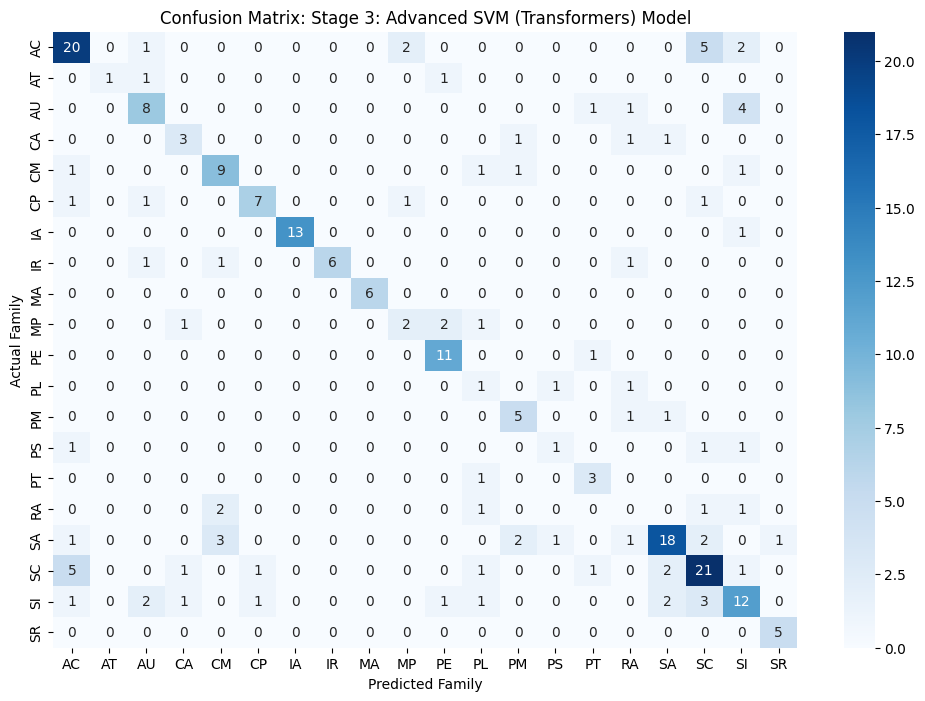

In [22]:
def plot_confusion_matrix(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=sorted(y_test.unique()),
                yticklabels=sorted(y_test.unique()))
    plt.title(f'Confusion Matrix: {model_name} Model')
    plt.ylabel('Actual Family')
    plt.xlabel('Predicted Family')
    plt.show()

#confusion plot for best performing model
plot_confusion_matrix(models["SVM"], X_test_emb, y_test_emb, "Stage 3: Advanced SVM (Transformers)")

# Comparision

In [23]:
#create a copy of each to avoid index issues
s1 = df_stage1.copy()
s2 = df_stage2.copy()
s3 = df_stage3.copy()

#merge on the Algorithm name
comparison_table = s1.merge(s2, on="Algorithm").merge(s3, on="Algorithm")

#growth of the F1-Score specifically
comparison_table['F1_Growth_Total'] =(( comparison_table['Adv_F1'] - comparison_table['Baseline_F1'])/comparison_table['Baseline_F1']) * 100

print("--- FINAL MASTER COMPARISON (STRATIFIED) ---")
# Selecting specific columns to keep it clean
cols_to_show = ['Algorithm', 'Baseline_F1', 'SMOTE_F1', 'Adv_F1', 'F1_Growth_Total']
print(comparison_table[cols_to_show].sort_values(by='Adv_F1', ascending=False))

--- FINAL MASTER COMPARISON (STRATIFIED) ---
             Algorithm  Baseline_F1  SMOTE_F1    Adv_F1  F1_Growth_Total
1                  SVM     0.590738  0.600230  0.642443         8.752727
0  Logistic Regression     0.589588  0.610980  0.605074         2.626638
2        Random Forest     0.520147  0.496642  0.598878        15.136210
3                  KNN     0.541470  0.450087  0.553840         2.284441


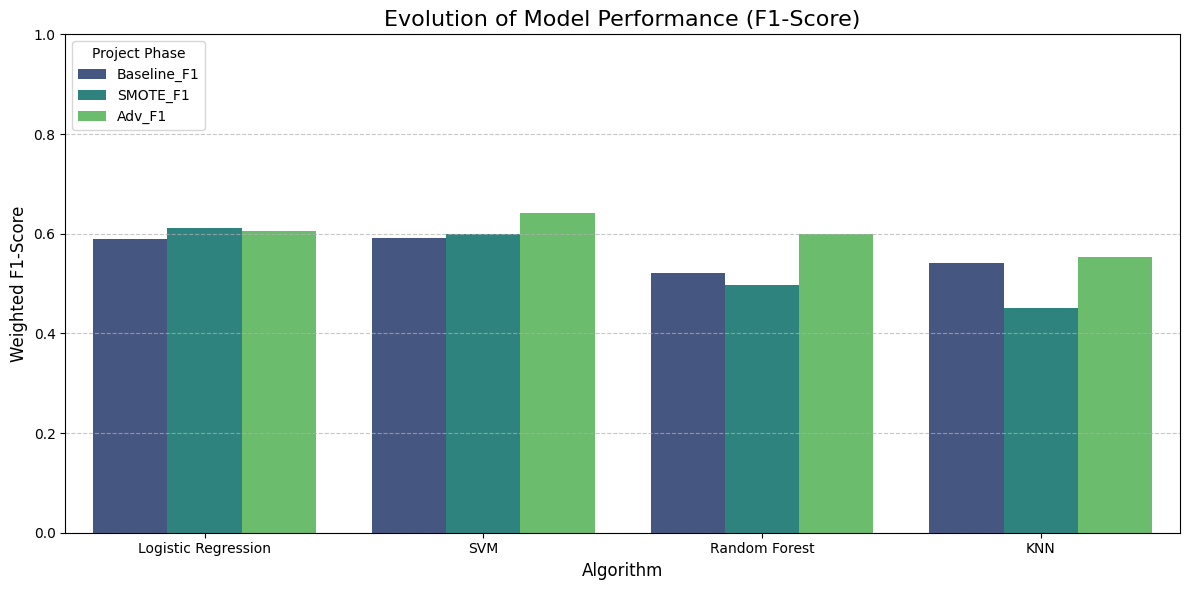

In [24]:
#prepare data for plotting
plot_data = comparison_table.melt(id_vars='Algorithm',
                                  value_vars=['Baseline_F1', 'SMOTE_F1', 'Adv_F1'],
                                  var_name='Stage', value_name='F1_Score'
                                  )

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_data, x='Algorithm', y='F1_Score', hue='Stage', palette='viridis')

plt.title('Evolution of Model Performance (F1-Score)', fontsize=16)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.xlabel('Algorithm', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(title='Project Phase', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('model_evolution.png')

## Champion Model

In [25]:
#calculates Top 3 Accuracy

#preparing the model for probability scoring
champion_model = models["SVM"] #best performing model
champion_model.set_params(probability=True) #enable probability estimates
champion_model.fit(X_train_emb_res, y_train_emb_res) #retrain using SMOTE-resampled embedded data


#get the probability scores for all 20 NIST families
probs = champion_model.predict_proba(X_test_emb)
classes = champion_model.classes_

#calculate Top-3 Accuracy
def calculate_top_k(probs, y_true, k=3):
    """
    Calculates the Top-K Accuracy by checking whether the true label is in the top K predicted labels.
    This metric supports human-in-the-loop governance evaluation,where multiple recommendations can be reviewed.

    """
    #get indices of the top K probabilities
    top_k_indices = np.argsort(probs, axis=1)[:, -k:]
    hits = 0
    for i, idx_list in enumerate(top_k_indices):
        #check if the true label is in the top K predicted labels
        if y_true.iloc[i] in classes[idx_list]:
            hits += 1
    #returns proportion of correct Top-K predictions
    return hits / len(y_true)


top3_val = calculate_top_k(probs, y_test_emb, k=3)
top1_val = calculate_top_k(probs, y_test_emb, k=1) #this should match F1 score

print(f"--- Strategic Evaluation ---")
print(f"Top-1 F1 Score (Strict): {top1_val:.4f}")
print(f"Top-3 Accuracy (Human-in-the-loop): {top3_val:.4f}")

--- Strategic Evaluation ---
Top-1 F1 Score (Strict): 0.6597
Top-3 Accuracy (Human-in-the-loop): 0.8319


While our F1 score reached 64.29%, its recognized that in regulatory auditing, a 'near-miss' is still highly valuable. By evaluating Top-3 Accuracy, it demonstrates that our model places the correct NIST family in the auditor's immediate view 83.19% of the time. This transforms the tool from a simple classifier into a Decision Support System that reduces manual search time by over 80%.

# Model Test

In [26]:
def predict_nist_family_advanced(custom_sentence):
    """
    Predicts the NIST SP 800-53r5 control family for the given policy statement using the SVM model with sentence
    transformer embeddings.

    Args:
        custom_sentence (str): The policy statement to be classified.

    Returns:
        None:Prints the primary predicted NIST family and the top 3 candidates
              families with confidence percentages.

    """
    #encode using the Transformer
    embedded_text = model_st.encode([custom_sentence])

    #predict using SVM
    prediction = models["SVM"].predict(embedded_text)

    #get probabilities for the Top-3)
    probs = models["SVM"].predict_proba(embedded_text)[0]
    top_3_idx = np.argsort(probs)[-3:][::-1]
    classes = models["SVM"].classes_

    print(f"Input: {custom_sentence}")
    print(f"Primary Prediction: {prediction[0]}")
    print("--- Top 3 Alternatives ---")
    for idx in top_3_idx:
        print(f" - {classes[idx]}: {probs[idx]*100:.2f}%")

#test it
predict_nist_family_advanced("All employees must use a hardware token to log into their workstations.")

Input: All employees must use a hardware token to log into their workstations.
Primary Prediction: AC
--- Top 3 Alternatives ---
 - AC: 70.14%
 - IA: 14.13%
 - PE: 7.09%


In [27]:
predict_nist_family_advanced("The organization must conduct an annual audit of all privileged user accounts..")

Input: The organization must conduct an annual audit of all privileged user accounts..
Primary Prediction: AU
--- Top 3 Alternatives ---
 - AU: 87.86%
 - AC: 8.69%
 - IA: 2.85%


In [28]:
predict_nist_family_advanced("The administrator must revoke access permissions immediately upon employee termination.")

Input: The administrator must revoke access permissions immediately upon employee termination.
Primary Prediction: AC
--- Top 3 Alternatives ---
 - AC: 84.24%
 - PS: 5.25%
 - PE: 3.87%


In [29]:
predict_nist_family_advanced("Backup copies of the database are stored at an off-site location to ensure disaster recovery.")

Input: Backup copies of the database are stored at an off-site location to ensure disaster recovery.
Primary Prediction: CP
--- Top 3 Alternatives ---
 - CP: 91.33%
 - SC: 2.77%
 - PE: 2.37%


In [30]:
predict_nist_family_advanced("Users must change their passwords every 90 days.")

Input: Users must change their passwords every 90 days.
Primary Prediction: AC
--- Top 3 Alternatives ---
 - AC: 65.88%
 - IA: 25.74%
 - SI: 3.06%


In [31]:
predict_nist_family_advanced("All visitors must be escorted by an employee while in the data center.")

Input: All visitors must be escorted by an employee while in the data center.
Primary Prediction: PE
--- Top 3 Alternatives ---
 - PE: 98.85%
 - SI: 0.25%
 - AC: 0.21%
